In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import numpy as np

from jax import jit
from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, points_on_circle


from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import *
from jwave.utils import show_field

import fbpinn_wave as fw

from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model

In [2]:
domain = Domain((2500, 2500), (0.1/2500, 0.1/2500))
medium = Medium(domain=domain, sound_speed=1490.0, attenuation=0.0, pml_size=30.0)
time_axis = TimeAxis.from_medium(medium, cfl=0.3, t_end=100e-6)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

El dominio espacial en x va de -0.04997999966144562 m a 0.04997999966144562 m
El dominio espacial en y va de -0.04997999966144562 m a 0.04997999966144562 m


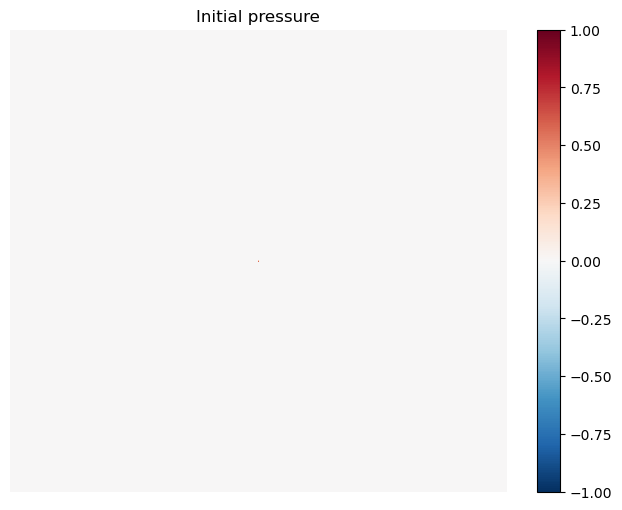

In [3]:

N = domain.N

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 0])/domain.dx[0] + np.array(N)/2
sigma = 1.5e-3/domain.dx[0]/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

p0 = FourierSeries(p0, domain)

show_field(p0)
plt.title("Initial pressure")
plt.show()

In [4]:
num_sensors = 64
rx = 45e-3
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

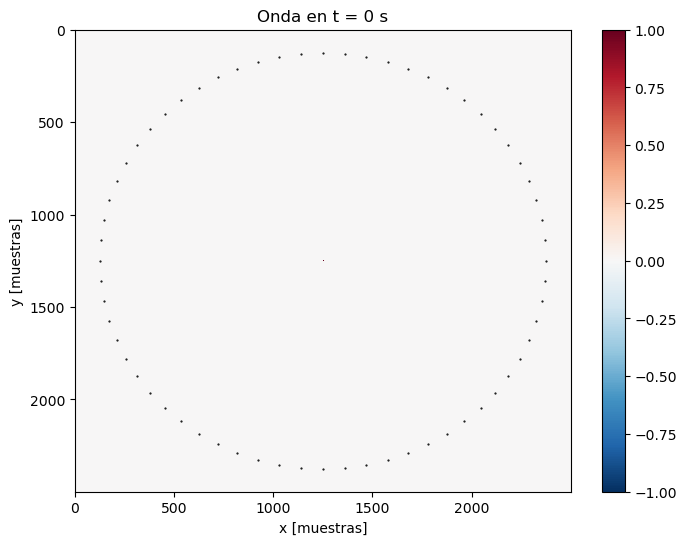

In [5]:

show_field(p0)
plt.scatter(xi, yi, c='black', s=0.3)
plt.title("Onda en t = 0 s")
plt.xlabel("x [muestras]")
plt.ylabel("y [muestras]")
plt.axis('on')
plt.axis()
plt.show()

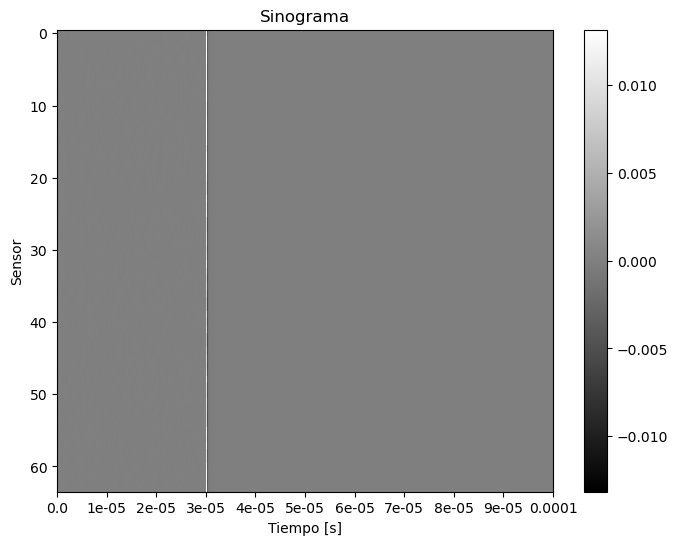

In [8]:
dt = time_axis.dt

#Se carga el sinograma previamente simulado en GPU
sinogram = np.load('sinogram_extended.npy')

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray", 
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)

plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=5))
plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
plt.show()

In [11]:
from trampa import WaveTrampa

WaveTrampa()

ri = 15e-3/domain.dx[0] # El de la red
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))

t = time_axis.to_array()
t = np.linspace(0, 35e-6/20, 300) # El máximo de tiempo entrenado por la red
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]/20 # Escalo acá en vez de en el radio porque si lo hago antes la precisión del círcuo es mala 
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]/20

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine1/results/")
_, all_params, _, active, _ = model

u = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)


[INFO] 2026-02-27 17:32:13 - Loading model from:
pulse_2d_real_extended_fine1/results/models/test/model_00200000.jax
[INFO] 2026-02-27 17:32:13 - x_batch
[INFO] 2026-02-27 17:32:13 - (19200, 3), float64, ndarray
[INFO] 2026-02-27 17:32:13 - x_take
[INFO] 2026-02-27 17:32:13 - (342400, 3), float64, ndarray


2.425e-08


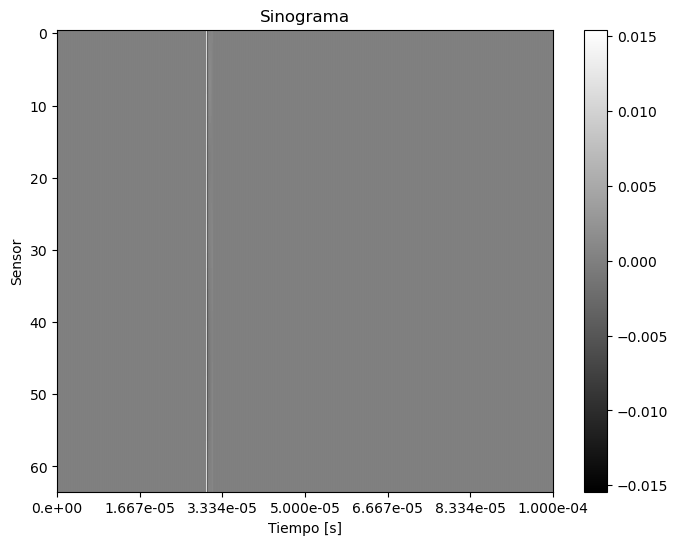

In [10]:
sinogram_fbpinn, t_new = fw.extend_sinogram(u, 15e-3/20, 1490.0, 45e-3, t[1]-t[0], 100e-6, n_resample=sinogram.shape[1], smooth=False)

ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 7
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = np.format_float_scientific((t_ticks[i]*(t_new[1]-t_new[0])), precision=3)
plt.xticks(t_ticks, t_string)
plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
print(ecm)
plt.show()

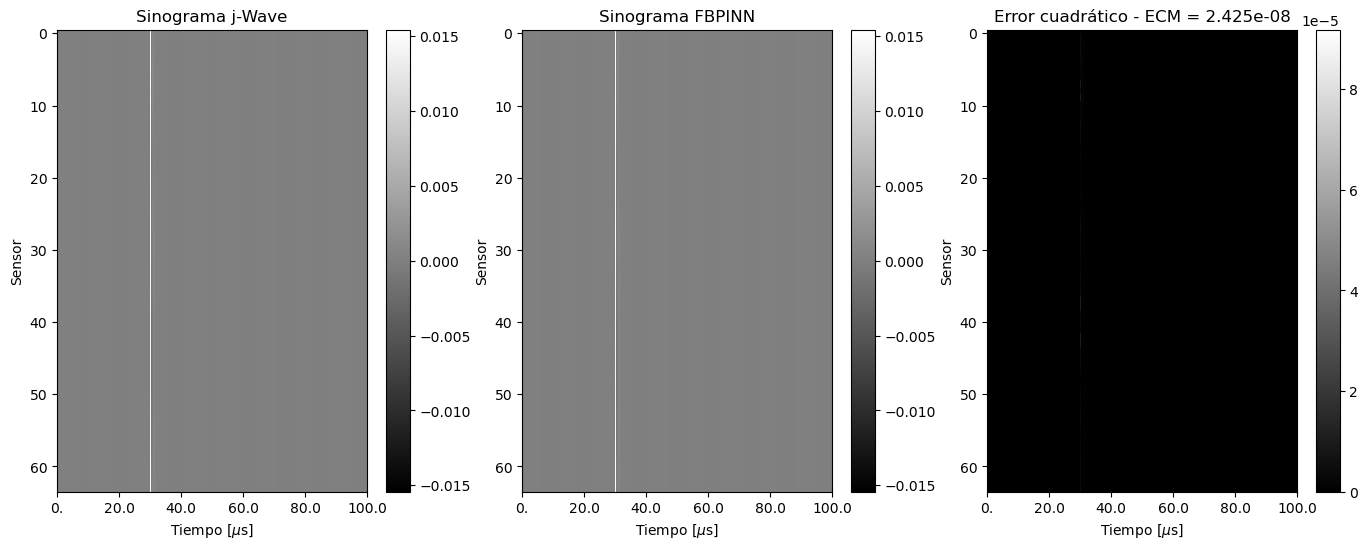

In [14]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(17,6))
plt.subplot(1,3,1)
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray", 
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 6

t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=1, )
plt.xticks(t_ticks, t_string)
plt.title("Sinograma j-Wave")
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")

plt.subplot(1,3,2)
plt.imshow(
    sinogram_fbpinn,
    cmap="gray", 
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()

num = 6
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=1, )

plt.xticks(t_ticks, t_string)
plt.title("Sinograma FBPINN")
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")

plt.subplot(1,3,3)
plt.imshow(
    ec,
    cmap="gray",
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()

num = 6
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] =np.format_float_positional((t_ticks[i]*(t_new[1]-t_new[0]))/1e-6, precision=1, )

plt.xticks(t_ticks, t_string)
plt.title("Error cuadrático - ECM = " + str(ecm))
plt.xlabel("Tiempo [$\mu$s]")
plt.ylabel("Sensor")
plt.show()

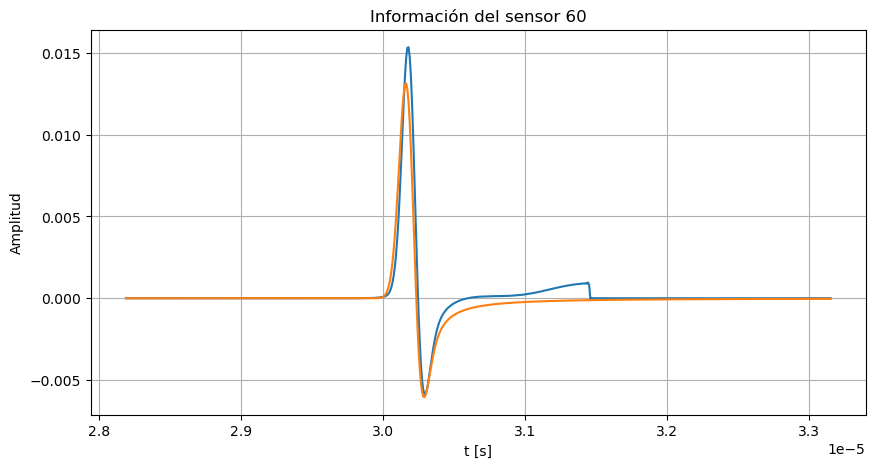

In [17]:
#Comparación por sensores

id = 60
start = 3500
end = 8300
sensor = sinogram[id,start:-end]
sensor_fbpinn = sinogram_fbpinn[id,start:-end]
t_axis = time_axis.to_array()

plt.figure(figsize=(10,5))

plt.subplot(1,1,1)
plt.title(f"Información del sensor {id}")
plt.plot(t_axis[start:-end], sensor_fbpinn)
plt.plot(t_axis[start:-end], sensor)
plt.grid()
plt.xlabel('t [s]')
plt.ylabel('Amplitud')
plt.show()

## Figuras de mérito

In [18]:
print("Para sinogramas:\n")
_ = fw.metricas_imagen(sinogram, sinogram_fbpinn)

Para sinogramas:

MSE = 2.425e-08
RMSE = 1.557e-04
PSNR = 42.977348229009856
SSIM = 0.9999826838870466
PCC = 0.9368333437848404


Para reconstrucciones con DAS entre sí:

MSE = 7.697e-04
RMSE = 2.774e-02
PSNR = 29.13211595152273
SSIM = 0.9390966822960893
PCC = 0.96884708571432

Para reconstrucciones con DAS respecto a la presión original:

j-wave:
MSE = 1.787e-03
RMSE = 4.228e-02
PSNR = 27.477637080446847
SSIM = 0.8572686265972048
PCC = 0.9143743554512241

FBPINNs
MSE = 2.007e-03
RMSE = 4.480e-02
PSNR = 26.973609772399186
SSIM = 0.8075818167718221
PCC = 0.9592786683279895


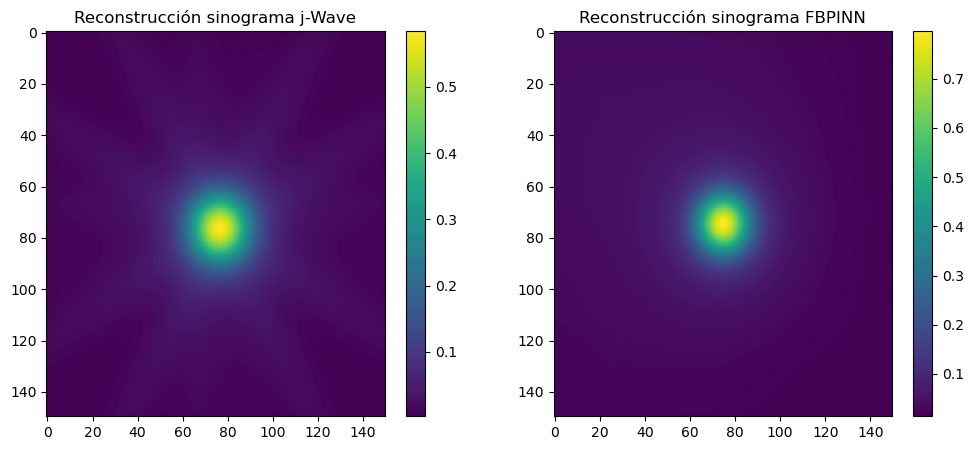

In [22]:
from delayandsum import applyDAS
Pjwave = applyDAS(sinogram.shape[0],sinogram.shape[1],10e-6,150,rx,360,1490,0,100e-6,sinogram).T
Pfbpinn = applyDAS(sinogram.shape[0],sinogram.shape[1],10e-6,150,rx,360,1490,0,100e-6,sinogram_fbpinn).T

N = [150,150]
dx = 10e-6

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 0])/dx + np.array(N)/2
sigma = 1.5e-3/dx/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Reconstrucción sinograma j-Wave')
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Reconstrucción sinograma FBPINN')
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.colorbar()


print("Para reconstrucciones con DAS entre sí:\n")
_ = fw.metricas_imagen(Pjwave, Pfbpinn)

print("\nPara reconstrucciones con DAS respecto a la presión original:\n")
print("j-wave:")
_ = fw.metricas_imagen(Pjwave, p0)
print("\nFBPINNs")
_ = fw.metricas_imagen(p0, Pfbpinn)